In [4]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import END, START
from langgraph.graph.state import StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_core.messages import BaseMessage
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
os.environ["LANGSMITH_PROJECT"]="TestProject"

In [6]:
import os
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["LANGSMITH_API_KEY"] = os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGSMITH_TRACING"] ="true"


In [7]:
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:openai/gpt-oss-120b")
llm

ChatGroq(client=<groq.resources.chat.completions.Completions object at 0x1159ac100>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x115cfdd90>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [8]:
class State(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [9]:
## Graph with tool call

from langchain_core.tools import tool

@tool
def add(a:float, b:float):
    """add two numbers"""
    return a+b


tools=[add]
tool_node=ToolNode([add])
llm_with_tool=llm.bind_tools([add])

def call_llm_model(state:State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]}

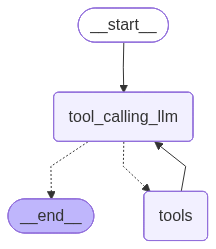

In [10]:
## Stategraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def call_llm_model(state:State):
    return {"messages":[llm_with_tool.invoke(state['messages'])]}
## Grpah
builder=StateGraph(State)
builder.add_node("tool_calling_llm",call_llm_model)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
response=graph.invoke({"messages":"What is machine learning"})

In [12]:
response

{'messages': [HumanMessage(content='What is machine learning', additional_kwargs={}, response_metadata={}, id='588f2a48-e6ed-4f12-ae6b-47c1bdedd9ab'),
  AIMessage(content='**Machine learning (ML)** is a sub‑field of artificial intelligence that focuses on building systems that can **learn from data** and improve their performance on a task without being explicitly programmed for every possible scenario.\n\n### Core Idea\n- **Data\u202f→\u202fPattern\u202f→\u202fModel\u202f→\u202fPrediction/Decision**  \n  An ML algorithm ingests examples (training data), discovers statistical patterns, creates a mathematical model that captures those patterns, and then uses the model to make predictions or decisions on new, unseen data.\n\n### How It Works\n1. **Collect Data** – Gather labeled (supervised) or unlabeled (unsupervised) examples.\n2. **Choose a Model** – Pick a family of functions (e.g., linear regression, decision trees, neural networks) that can represent the relationship you’re trying 

In [13]:
response=graph.invoke({"messages":"can you add 5 and 6?"})

In [14]:
response

{'messages': [HumanMessage(content='can you add 5 and 6?', additional_kwargs={}, response_metadata={}, id='5faba6cc-7c7b-41bd-9e42-ebd1565a71f8'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to call add function with a=5,b=6.', 'tool_calls': [{'id': 'fc_575bdc90-20f4-4d58-be40-c17e33543c0e', 'function': {'arguments': '{"a":5,"b":6}', 'name': 'add'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 129, 'total_tokens': 177, 'completion_time': 0.100873087, 'completion_tokens_details': {'reasoning_tokens': 15}, 'prompt_time': 0.005485602, 'prompt_tokens_details': None, 'queue_time': 0.051287618, 'total_time': 0.106358689}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_45f51928b5', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--019e03df-68e0-77f2-bf53-65be8ef5f92b-0', tool_calls=[{'name': 'add', 'args': {'a': 5, 'b': 6}, 'id': 'fc_575bdc90-20f4-4d58-be40